This step evaluates the temporal availability of the historical and recent detector datasets for the selected intersections. Since the older JSON files and the newer JSON files have slightly different internal structures, a unified parser is used to extract the common traffic count information. The goal is to identify full, partial, and empty days and to determine which periods are suitable for subsequent approach-based aggregation and LSTM modeling.
****

**1**
read both: 

old 2025 files

recent 2026 files

handle both JSON styles

keep only what we need for now:

timestamp

detector id

count

classify days into:

full

partial

empty

compute longest continuous usable block

tell you which days are suitable for modeling

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")

HIST_BASE = BASE_DIR / "Six_Months_Data"
RECENT_BASE = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell")

LSA_FOLDERS = ["LD-LSA1", "LD-LSA10", "LD-LSA16"]

OUT_DIR = BASE_DIR / "historical_availability_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_LONG_CSV = OUT_DIR / "historical_recent_raw_long.csv"
FILE_SUMMARY_CSV = OUT_DIR / "historical_recent_file_summary.csv"
DAY_SUMMARY_CSV = OUT_DIR / "historical_recent_day_summary.csv"

TIMEZONE_LOCAL = "Europe/Berlin"
EXPECTED_BINS_PER_DAY = 96

# ============================================================
# HELPERS
# ============================================================

def parse_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_date_from_filename(path: Path):
    """
    Handles:
    - 2025-06-12.json
    - 2026-04-01_0000.json
    """
    return path.stem[:10]

def safe_get(dct, keys, default=np.nan):
    cur = dct
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

# ============================================================
# COLLECT FILES
# ============================================================

all_rows = []
file_rows = []

for lsa in LSA_FOLDERS:
    hist_dir = HIST_BASE / lsa
    recent_dir = RECENT_BASE / lsa

    hist_files = sorted(hist_dir.glob("*.json")) if hist_dir.exists() else []
    recent_files = sorted(recent_dir.glob("*.json")) if recent_dir.exists() else []

    all_files = [(p, "historical") for p in hist_files] + [(p, "recent") for p in recent_files]

    print(f"{lsa}: {len(hist_files)} historical files, {len(recent_files)} recent files")

    for path, source_period in all_files:
        try:
            data = parse_json_file(path)
        except Exception as e:
            file_rows.append({
                "lsa": lsa,
                "source_period": source_period,
                "file_name": path.name,
                "date_from_name": extract_date_from_filename(path),
                "read_ok": False,
                "error": str(e),
                "n_timeframes": np.nan,
                "empty_timeframes_list": np.nan
            })
            continue

        timeframes = data.get("timeFrames", [])

        file_rows.append({
            "lsa": lsa,
            "source_period": source_period,
            "file_name": path.name,
            "date_from_name": extract_date_from_filename(path),
            "read_ok": True,
            "error": "",
            "n_timeframes": len(timeframes),
            "empty_timeframes_list": len(timeframes) == 0
        })

        for tf in timeframes:
            ts_utc = tf.get("timestamp")
            detectors = tf.get("detectors", [])

            if len(detectors) == 0:
                all_rows.append({
                    "lsa": lsa,
                    "source_period": source_period,
                    "source_file": path.name,
                    "date_from_name": extract_date_from_filename(path),
                    "timestamp_utc": ts_utc,
                    "detector_id": np.nan,
                    "count": np.nan,
                    "timeframe_exists": True,
                    "detector_data_exists": False
                })
                continue

            for det in detectors:
                all_rows.append({
                    "lsa": lsa,
                    "source_period": source_period,
                    "source_file": path.name,
                    "date_from_name": extract_date_from_filename(path),
                    "timestamp_utc": ts_utc,
                    "detector_id": safe_get(det, ["id"]),
                    "count": safe_get(det, ["reading", "count", "value"]),
                    "timeframe_exists": True,
                    "detector_data_exists": True
                })

raw_df = pd.DataFrame(all_rows)
file_df = pd.DataFrame(file_rows)

# ============================================================
# TIMESTAMPS
# ============================================================

raw_df["timestamp_utc"] = pd.to_datetime(raw_df["timestamp_utc"], utc=True, errors="coerce")
raw_df["timestamp_berlin"] = raw_df["timestamp_utc"].dt.tz_convert(TIMEZONE_LOCAL)
raw_df["date_berlin"] = raw_df["timestamp_berlin"].dt.strftime("%Y-%m-%d")
raw_df["time_berlin"] = raw_df["timestamp_berlin"].dt.strftime("%H:%M")

# ============================================================
# SAVE FILE SUMMARY
# ============================================================

file_df.to_csv(FILE_SUMMARY_CSV, index=False, encoding="utf-8-sig")

# ============================================================
# DAY SUMMARY
# ============================================================

day_file_base = file_df[[
    "lsa", "source_period", "file_name", "date_from_name",
    "read_ok", "n_timeframes", "empty_timeframes_list"
]].copy()

day_file_base = day_file_base.rename(columns={"date_from_name": "date_str"})

tf_level = (
    raw_df.groupby(["lsa", "source_period", "timestamp_utc", "date_berlin"], as_index=False)
    .agg(
        detector_data_exists=("detector_data_exists", "max"),
        n_detector_records=("detector_id", lambda s: s.notna().sum()),
        timestamp_berlin=("timestamp_berlin", "first")
    )
)

day_stats = (
    tf_level.groupby(["lsa", "source_period", "date_berlin"], as_index=False)
    .agg(
        n_timeframes_present=("timestamp_utc", "nunique"),
        n_timeframes_with_detector_data=("detector_data_exists", lambda s: int(s.sum())),
        n_detector_records=("n_detector_records", "sum"),
        first_timestamp=("timestamp_berlin", "min"),
        last_timestamp=("timestamp_berlin", "max"),
    )
    .rename(columns={"date_berlin": "date_str"})
)

day_summary = day_file_base.merge(
    day_stats,
    on=["lsa", "source_period", "date_str"],
    how="left"
)

day_summary["expected_bins_per_day"] = EXPECTED_BINS_PER_DAY
day_summary["coverage_ratio"] = (
    day_summary["n_timeframes_with_detector_data"].fillna(0) / EXPECTED_BINS_PER_DAY
)

day_summary["day_status"] = np.select(
    [
        day_summary["read_ok"] == False,
        day_summary["empty_timeframes_list"] == True,
        day_summary["n_timeframes_with_detector_data"].fillna(0) == 0,
        day_summary["n_timeframes_with_detector_data"].fillna(0) < EXPECTED_BINS_PER_DAY,
        day_summary["n_timeframes_with_detector_data"].fillna(0) >= EXPECTED_BINS_PER_DAY
    ],
    [
        "read_error",
        "empty_day",
        "timeframes_but_no_detector_data",
        "partial_day",
        "full_day"
    ],
    default="unknown"
)

# ============================================================
# CONTINUOUS COVERAGE CHECK
# ============================================================

usable_rows = []

for (lsa, source_period, date_str), grp in tf_level.groupby(["lsa", "source_period", "date_berlin"]):
    grp = grp.sort_values("timestamp_utc").copy()
    grp["has_data"] = grp["detector_data_exists"].astype(int)

    max_continuous_bins = 0
    current_run = 0

    for v in grp["has_data"]:
        if v == 1:
            current_run += 1
            max_continuous_bins = max(max_continuous_bins, current_run)
        else:
            current_run = 0

    usable_rows.append({
        "lsa": lsa,
        "source_period": source_period,
        "date_str": date_str,
        "max_continuous_bins_with_data": max_continuous_bins,
        "max_continuous_hours_with_data": max_continuous_bins * 0.25
    })

usable_df = pd.DataFrame(usable_rows)

day_summary = day_summary.merge(
    usable_df,
    on=["lsa", "source_period", "date_str"],
    how="left"
)

day_summary["model_usability"] = np.select(
    [
        day_summary["day_status"] == "full_day",
        (day_summary["day_status"] == "partial_day") & (day_summary["max_continuous_bins_with_data"].fillna(0) >= 16),
        day_summary["day_status"] == "partial_day"
    ],
    [
        "usable",
        "usable_partial",
        "not_recommended"
    ],
    default="not_usable"
)

# ============================================================
# SAVE
# ============================================================

raw_df.to_csv(RAW_LONG_CSV, index=False, encoding="utf-8-sig")
day_summary.to_csv(DAY_SUMMARY_CSV, index=False, encoding="utf-8-sig")

print("\nSaved:")
print(RAW_LONG_CSV)
print(FILE_SUMMARY_CSV)
print(DAY_SUMMARY_CSV)

print("\nDay status counts by LSA and source:")
print(day_summary.groupby(["lsa", "source_period", "day_status"]).size())

print("\nUsable day counts by LSA and source:")
print(day_summary.groupby(["lsa", "source_period", "model_usability"]).size())

LD-LSA1: 175 historical files, 47 recent files
LD-LSA10: 175 historical files, 47 recent files
LD-LSA16: 175 historical files, 47 recent files

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\historical_availability_analysis\historical_recent_raw_long.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\historical_availability_analysis\historical_recent_file_summary.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\historical_availability_analysis\historical_recent_day_summary.csv

Day status counts by LSA and source:
lsa       source_period  day_status 
LD-LSA1   historical     empty_day      145
                         full_day        28
                         partial_day      2
          recent         empty_day        3
                         full_day        13
                         partial_day     31
LD-LSA10  historical     empty_day       39
                         full_day       126
                         partial_day     10
          recent       

LSA16
historical: 170 full usable days
recent: 14 full + 29 usable partial
this is an candidate for the first intersection-level LSTM

LSA10
historical: 126 full usable days
recent: 13 full + 34 usable partial
also strong

LSA1
historical: only 28 full usable days
recent: 13 full + 27 usable partial
still usable, but less robust than LSA16/10

***
**LSA16-specific output folder + usable-day extraction**
***

In [2]:
from pathlib import Path
import pandas as pd

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
DAY_SUMMARY_CSV = BASE_DIR / "historical_availability_analysis" / "historical_recent_day_summary.csv"

LSA_NAME = "LD-LSA16"
OUT_DIR = BASE_DIR / "LSA16"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_USABLE_DAYS_CSV = OUT_DIR / "LSA16_usable_days.csv"
OUT_DAY_STATUS_CSV = OUT_DIR / "LSA16_day_status_summary.csv"

# ============================================================
# LOAD
# ============================================================

day_summary = pd.read_csv(DAY_SUMMARY_CSV)

# ============================================================
# FILTER FOR LSA16
# ============================================================

lsa_day_summary = day_summary[day_summary["lsa"] == LSA_NAME].copy()

usable_days = lsa_day_summary[
    lsa_day_summary["model_usability"].isin(["usable", "usable_partial"])
].copy()

usable_days = usable_days.sort_values(["date_str", "source_period"]).reset_index(drop=True)

# save
lsa_day_summary.to_csv(OUT_DAY_STATUS_CSV, index=False, encoding="utf-8-sig")
usable_days.to_csv(OUT_USABLE_DAYS_CSV, index=False, encoding="utf-8-sig")

print("Saved:")
print(OUT_DAY_STATUS_CSV)
print(OUT_USABLE_DAYS_CSV)

print("\nUsable day counts:")
print(usable_days.groupby(["source_period", "model_usability"]).size())

print("\nFirst usable days:")
print(usable_days[["date_str", "source_period", "day_status", "model_usability"]].head(20))

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA16\LSA16_day_status_summary.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA16\LSA16_usable_days.csv

Usable day counts:
source_period  model_usability
historical     usable             170
               usable_partial       5
recent         usable              14
               usable_partial      29
dtype: int64

First usable days:
      date_str source_period   day_status model_usability
0   2025-01-01    historical  partial_day  usable_partial
1   2025-01-02    historical     full_day          usable
2   2025-01-03    historical     full_day          usable
3   2025-01-04    historical     full_day          usable
4   2025-01-05    historical     full_day          usable
5   2025-01-06    historical     full_day          usable
6   2025-01-07    historical     full_day          usable
7   2025-01-08    historical     full_day          usable
8   2025-01-09    historical     full_day          usable
9   2025-0

**Approach-based count aggregation for LSA16**

This step combines the historical and recent detector JSON files for LSA16 and aggregates the selected detector counts to the approach level. The result is a continuous 15-minute approach-based traffic count dataset for the west, south, east, and north inflow directions of LSA16, which forms the basis for intersection-specific forecasting.

In [21]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")

HIST_DIR = BASE_DIR / "Six_Months_Data" / "LD-LSA16"
RECENT_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\LD-LSA16")

OUT_DIR = BASE_DIR / "LSA16"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_RAW_CSV = OUT_DIR / "LSA16_raw_long.csv"
OUT_APPROACH_CSV = OUT_DIR / "LSA16_approach_counts_15min.csv"
OUT_MAPPING_CSV = OUT_DIR / "LSA16_mapping_summary.csv"

TIMEZONE_LOCAL = "Europe/Berlin"

# ============================================================
# LSA16 MAPPING
# ============================================================

LSA16_MAPPING = {
    "street_names": {
        "west": "Schloßstraße",
        "south": "Weißenburger Straße",
        "east": "Schloßstraße",
        "north": "Xylanderstraße",
    },
    "inflow": {
        "west":  [4, 3],
        "south": [33, 2, 1],
        "east":  [10, 11],
        "north": [6, 7],
    },
    "outflow": {
        "east_exit": [15],
        "west_to_LSA10": [13],
    }
}

# ============================================================
# HELPERS
# ============================================================

def parse_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_date_from_filename(path: Path):
    return path.stem[:10]

def safe_get(dct, keys, default=np.nan):
    cur = dct
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

# ============================================================
# READ FILES
# ============================================================

all_files = []
if HIST_DIR.exists():
    all_files += [(p, "historical") for p in sorted(HIST_DIR.glob("*.json"))]
if RECENT_DIR.exists():
    all_files += [(p, "recent") for p in sorted(RECENT_DIR.glob("*.json"))]

rows = []

for path, source_period in all_files:
    try:
        data = parse_json_file(path)
    except Exception as e:
        print(f"Could not read {path.name}: {e}")
        continue

    timeframes = data.get("timeFrames", [])

    for tf in timeframes:
        ts_utc = tf.get("timestamp")
        detectors = tf.get("detectors", [])

        if len(detectors) == 0:
            continue

        for det in detectors:
            rows.append({
                "source_period": source_period,
                "source_file": path.name,
                "date_from_name": extract_date_from_filename(path),
                "timestamp_utc": ts_utc,
                "detector_id": safe_get(det, ["id"]),
                "count": safe_get(det, ["reading", "count", "value"]),
            })

raw_df = pd.DataFrame(rows)

# ============================================================
# CLEAN / TIMESTAMPS
# ============================================================

raw_df["timestamp_utc"] = pd.to_datetime(raw_df["timestamp_utc"], utc=True, errors="coerce")
raw_df["timestamp_berlin"] = raw_df["timestamp_utc"].dt.tz_convert(TIMEZONE_LOCAL)
raw_df["detector_id"] = pd.to_numeric(raw_df["detector_id"], errors="coerce")
raw_df["count"] = pd.to_numeric(raw_df["count"], errors="coerce")

raw_df = raw_df.dropna(subset=["timestamp_berlin", "detector_id", "count"]).copy()
raw_df = raw_df.sort_values("timestamp_berlin").reset_index(drop=True)

raw_df.to_csv(OUT_RAW_CSV, index=False, encoding="utf-8-sig")

print("Saved raw long table:")
print(OUT_RAW_CSV)
print("Raw shape:", raw_df.shape)

# ============================================================
# SAVE MAPPING SUMMARY
# ============================================================

mapping_rows = []
for approach, dets in LSA16_MAPPING["inflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA16",
        "approach": approach,
        "street_name": LSA16_MAPPING["street_names"].get(approach, ""),
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "inflow"
    })

for approach, dets in LSA16_MAPPING["outflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA16",
        "approach": approach,
        "street_name": "",
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "outflow"
    })

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.to_csv(OUT_MAPPING_CSV, index=False, encoding="utf-8-sig")

print("\nSaved mapping summary:")
print(OUT_MAPPING_CSV)

# ============================================================
# AGGREGATE INFLOW COUNTS
# ============================================================

approach_tables = []

for approach, dets in LSA16_MAPPING["inflow"].items():
    temp = raw_df[raw_df["detector_id"].isin(dets)].copy()

    agg = (
        temp.groupby("timestamp_berlin", as_index=False)
        .agg(count=("count", "sum"))
    )

    agg = agg.rename(columns={"count": f"LSA16_{approach}_count"})
    approach_tables.append(agg)

# merge all approaches
approach_df = None
for tbl in approach_tables:
    if approach_df is None:
        approach_df = tbl.copy()
    else:
        approach_df = approach_df.merge(tbl, on="timestamp_berlin", how="outer")

approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], errors="coerce")
approach_df = approach_df.sort_values("timestamp_berlin").reset_index(drop=True)

# helper columns
approach_df["date"] = approach_df["timestamp_berlin"].dt.strftime("%Y-%m-%d")
approach_df["time"] = approach_df["timestamp_berlin"].dt.strftime("%H:%M")
approach_df["hour"] = approach_df["timestamp_berlin"].dt.hour
approach_df["weekday"] = approach_df["timestamp_berlin"].dt.day_name()

approach_df.to_csv(OUT_APPROACH_CSV, index=False, encoding="utf-8-sig")

print("\nSaved LSA16 approach dataset:")
print(OUT_APPROACH_CSV)
print("Approach shape:", approach_df.shape)
print("\nPreview:")
print(approach_df.head())

Saved raw long table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA16\LSA16_raw_long.csv
Raw shape: (682704, 7)

Saved mapping summary:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA16\LSA16_mapping_summary.csv

Saved LSA16 approach dataset:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA16\LSA16_approach_counts_15min.csv
Approach shape: (20688, 9)

Preview:
           timestamp_berlin  LSA16_west_count  LSA16_south_count  \
0 2025-01-01 01:00:00+01:00                16                 25   
1 2025-01-01 01:15:00+01:00                28                 23   
2 2025-01-01 01:30:00+01:00                30                 23   
3 2025-01-01 01:45:00+01:00                33                 34   
4 2025-01-01 02:00:00+01:00                20                 34   

   LSA16_east_count  LSA16_north_count        date   time  hour    weekday  
0                37                 17  2025-01-01  01:00     1  Wednesday  
1                38                 21  2025-01-0

 *** 
### **Exploratory analysis of the LSA16 approach-based dataset**

This step checks the completeness and temporal structure of the LSA16 approach-level count dataset and visualizes the main traffic patterns before forecasting.

In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA16")
APPROACH_CSV = BASE_DIR / "LSA16_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

# safer parsing for mixed +01:00 / +02:00 timestamps
df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")

# convert to Europe/Berlin local time and remove timezone for easier plotting/grouping
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA16_west_count",
    "LSA16_south_count",
    "LSA16_east_count",
    "LSA16_north_count",
]

print("Shape:", df.shape)

print("\nMissing values per count column:")
print(df[count_cols].isna().sum())

print("\nTime range:")
print(df["timestamp_berlin"].min(), "to", df["timestamp_berlin"].max())

# time gap check
time_diff = df["timestamp_berlin"].diff().value_counts().sort_index()
print("\nMost common time differences:")
print(time_diff.head(10))

print("\nBasic statistics:")
print(df[count_cols].describe())

Shape: (20688, 9)

Missing values per count column:
LSA16_west_count     0
LSA16_south_count    0
LSA16_east_count     0
LSA16_north_count    0
dtype: int64

Time range:
2025-01-01 01:00:00 to 2026-04-16 08:45:00

Most common time differences:
timestamp_berlin
0 days 00:15:00      20654
0 days 00:30:00         29
0 days 01:15:00          2
0 days 07:30:00          1
254 days 03:45:00        1
Name: count, dtype: int64

Basic statistics:
       LSA16_west_count  LSA16_south_count  LSA16_east_count  \
count      20688.000000       20688.000000      20688.000000   
mean          39.227088          58.808536         65.330095   
std           29.707443          41.204859         49.907868   
min            0.000000           0.000000          0.000000   
25%            8.000000          16.000000         15.000000   
50%           39.000000          61.000000         62.000000   
75%           65.000000          95.000000        105.000000   
max          135.000000         291.000000     

**Interpretation of the LSA16 exploratory analysis**

The exploratory analysis shows that the LSA16 approach-level dataset is largely complete and well structured for forecasting purposes. All four aggregated inflow count series are available without missing values, and the temporal resolution is predominantly consistent at 15-minute intervals. The dataset covers the period from January 2025 to April 2026 and contains 20,688 approach-based observations. Descriptive statistics indicate that the east and south approaches carry the highest average traffic volumes, while the north approach shows the lowest average demand but includes at least one unusually high peak, suggesting a potential outlier. The time-difference analysis further reveals that most observations are consecutive at 15-minute spacing, although a limited number of short gaps and one major gap between the historical and recent datasets are present. This confirms that LSA16 is highly suitable for intersection-specific forecasting, while also indicating that sequence generation should avoid spanning large discontinuities in the time series.
## I will train the model on past observed traffic patterns and evaluate whether it can generalize to a later unseen period.

Because the LSA16 dataset consists of a historical block and a separate recent block with a large temporal gap in between, the forecasting workflow is defined blockwise rather than treating the entire series as one continuous sequence. The historical data are used for model training, while the recent data are reserved for validation and testing. This avoids constructing invalid sequences across the long interruption between the two periods and provides a realistic evaluation of how well the model generalizes from past traffic patterns to a later unseen time period.

**1)Blockwise split for LSA16 forecasting**
Since the LSA16 dataset contains a historical block and a separate recent block, the modeling workflow is defined blockwise. The historical data are used for training, while the recent data are divided into validation and test subsets. This avoids constructing sequences across the long temporal gap between the two periods.

In [23]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA16")
APPROACH_CSV = BASE_DIR / "LSA16_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

# Safe timestamp parsing
df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA16_west_count",
    "LSA16_south_count",
    "LSA16_east_count",
    "LSA16_north_count",
]

data = df[["timestamp_berlin"] + count_cols].copy()
data[count_cols] = data[count_cols].ffill().bfill()

# ============================================================
# BLOCKWISE SPLIT
# ============================================================

historical_df = data[data["timestamp_berlin"] < "2026-01-01"].copy()
recent_df = data[data["timestamp_berlin"] >= "2026-01-01"].copy()

print("Historical shape:", historical_df.shape)
print("Recent shape:", recent_df.shape)

print("\nHistorical range:")
print(historical_df["timestamp_berlin"].min(), "to", historical_df["timestamp_berlin"].max())

print("\nRecent range:")
print(recent_df["timestamp_berlin"].min(), "to", recent_df["timestamp_berlin"].max())

Historical shape: (16714, 5)
Recent shape: (3974, 5)

Historical range:
2025-01-01 01:00:00 to 2025-06-24 11:45:00

Recent range:
2026-03-05 15:30:00 to 2026-04-16 08:45:00


**2) Validation-test split within the recent period**
The recent data are split chronologically into validation and test subsets in order to preserve the temporal order of observations.

In [24]:
# ============================================================
# SPLIT RECENT INTO VALIDATION / TEST
# ============================================================

n_recent = len(recent_df)
val_end = int(n_recent * 0.50)

val_df = recent_df.iloc[:val_end].copy()
test_df = recent_df.iloc[val_end:].copy()
train_df = historical_df.copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain range:")
print(train_df["timestamp_berlin"].min(), "to", train_df["timestamp_berlin"].max())

print("\nValidation range:")
print(val_df["timestamp_berlin"].min(), "to", val_df["timestamp_berlin"].max())

print("\nTest range:")
print(test_df["timestamp_berlin"].min(), "to", test_df["timestamp_berlin"].max())

Train: (16714, 5)
Validation: (1987, 5)
Test: (1987, 5)

Train range:
2025-01-01 01:00:00 to 2025-06-24 11:45:00

Validation range:
2026-03-05 15:30:00 to 2026-03-26 13:30:00

Test range:
2026-03-26 13:45:00 to 2026-04-16 08:45:00


**3)Sequence generation for LSA16**
The approach-based traffic count series are transformed into sequential samples for one-step-ahead forecasting. The previous four 15-minute observations are used to predict the next 15-minute traffic state.


In [25]:
# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 4
HORIZON = 1

# ============================================================
# SCALE USING TRAIN ONLY
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[count_cols])

train_scaled = scaler.transform(train_df[count_cols])
val_scaled = scaler.transform(val_df[count_cols])
test_scaled = scaler.transform(test_df[count_cols])

# ============================================================
# SEQUENCE FUNCTION
# ============================================================

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK, HORIZON)
X_val, y_val = create_sequences(val_scaled, LOOKBACK, HORIZON)
X_test, y_test = create_sequences(test_scaled, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
print("X_test: ", X_test.shape, "y_test:", y_test.shape)

X_train: (16710, 4, 4) y_train: (16710, 4)
X_val:   (1983, 4, 4) y_val: (1983, 4)
X_test:  (1983, 4, 4) y_test: (1983, 4)


**4) Naive baseline for LSA16**
A persistence-based baseline is used as a benchmark. It predicts that the next traffic state is equal to the most recent observed state.

In [26]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Naive prediction = last observed step in the input sequence
y_pred_naive_scaled = X_test[:, -1, :]

# Back to original counts
y_test_actual = scaler.inverse_transform(y_test)
y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
overall_mse_naive = mean_squared_error(y_test_actual, y_pred_naive_actual)
overall_rmse_naive = np.sqrt(overall_mse_naive)

print("LSA16 Naive baseline:")
print("MAE :", round(overall_mae_naive, 3))
print("MSE :", round(overall_mse_naive, 3))
print("RMSE:", round(overall_rmse_naive, 3))

LSA16 Naive baseline:
MAE : 9.304
MSE : 215.071
RMSE: 14.665


**LSTM model for LSA16**
An LSTM model is trained to predict the next 15-minute traffic counts for the four inflow approaches of LSA16.

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, n_features)),
    Dropout(0.2),
    Dense(n_features)
])

model.compile(optimizer="adam", loss="mse")

model.summary()

c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,924 (70.02 KB)

 Trainable params: 17,924 (70.02 KB)

 Non-trainable params: 0 (0.00 B)

**6) Training of the LSTM model**
The model is trained on the historical data and validated on the early recent period. Early stopping is used to reduce overfitting.


In [28]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0123 - val_loss: 0.0049
Epoch 2/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 3/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0041 - val_loss: 0.0048
Epoch 4/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0039 - val_loss: 0.0044
Epoch 5/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0037 - val_loss: 0.0043
Epoch 6/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0036 - val_loss: 0.0043
Epoch 7/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0036 - val_loss: 0.0043
Epoch 8/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0035 - val_loss: 0.0042
Epoch 9/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0035 - val_loss: 0.0042
Epoch 10/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0035 - val_loss: 0.0043
Epoch 11/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0036 - val_loss: 0.0043
Epoch 12/30
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

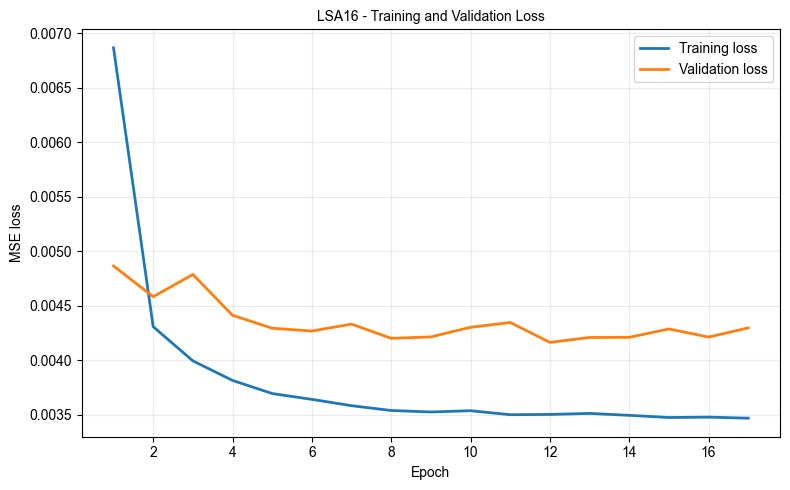

   epoch  train_loss  val_loss
0      1    0.006868  0.004867
1      2    0.004310  0.004585
2      3    0.003996  0.004789
3      4    0.003817  0.004414
4      5    0.003696  0.004295


In [29]:
import matplotlib.pyplot as plt
import pandas as pd

loss_df = pd.DataFrame({
    "epoch": range(1, len(history.history["loss"]) + 1),
    "train_loss": history.history["loss"],
    "val_loss": history.history["val_loss"]
})

plt.figure(figsize=(8, 5))
plt.plot(loss_df["epoch"], loss_df["train_loss"], label="Training loss", linewidth=2)
plt.plot(loss_df["epoch"], loss_df["val_loss"], label="Validation loss", linewidth=2)
plt.title("LSA16 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(loss_df.head())

**7)Evaluation of the LSA16 LSTM model**
The trained LSTM model is evaluated on the unseen recent test period and compared with the naive baseline.

In [30]:
y_pred_lstm_scaled = model.predict(X_test)
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
overall_mse_lstm = mean_squared_error(y_test_actual, y_pred_lstm_actual)
overall_rmse_lstm = np.sqrt(overall_mse_lstm)

print("LSA16 Naive baseline:")
print("MAE :", round(overall_mae_naive, 3))
print("MSE :", round(overall_mse_naive, 3))
print("RMSE:", round(overall_rmse_naive, 3))

print("\nLSA16 LSTM:")
print("MAE :", round(overall_mae_lstm, 3))
print("MSE :", round(overall_mse_lstm, 3))
print("RMSE:", round(overall_rmse_lstm, 3))

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
LSA16 Naive baseline:
MAE : 9.304
MSE : 215.071
RMSE: 14.665

LSA16 LSTM:
MAE : 7.646
MSE : 139.272
RMSE: 11.801


   model       MAE         MSE       RMSE
0  Naive  9.303580  215.071357  14.665311
1   LSTM  7.646044  139.272451  11.801375


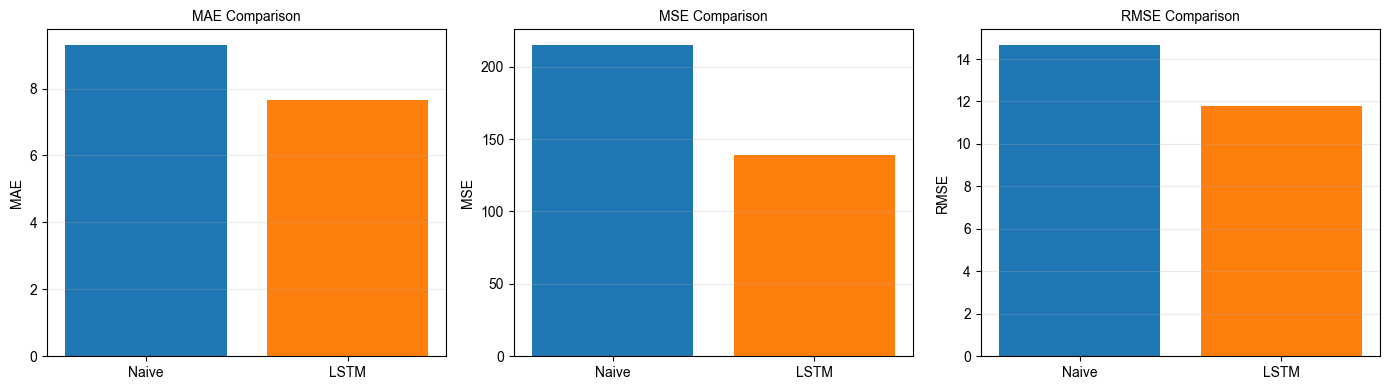

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

metrics_df = pd.DataFrame({
    "model": ["Naive", "LSTM"],
    "MAE": [overall_mae_naive, overall_mae_lstm],
    "MSE": [overall_mse_naive, overall_mse_lstm],
    "RMSE": [overall_rmse_naive, overall_rmse_lstm]
})

print(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(metrics_df["model"], metrics_df["MAE"], color=["tab:blue", "tab:orange"])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(metrics_df["model"], metrics_df["MSE"], color=["tab:blue", "tab:orange"])
axes[1].set_title("MSE Comparison")
axes[1].set_ylabel("MSE")
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(metrics_df["model"], metrics_df["RMSE"], color=["tab:blue", "tab:orange"])
axes[2].set_title("RMSE Comparison")
axes[2].set_ylabel("RMSE")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

per-approach MAE and RMSE 

  approach  naive_MAE  lstm_MAE   naive_MSE    lstm_MSE  naive_RMSE  lstm_RMSE
0     west   9.481594  7.627477  189.333333  118.415725   13.759845  10.881899
1    south  10.966213  9.106037  249.975794  157.685301   15.810623  12.557281
2     east  10.043873  8.483517  210.489662  153.044414   14.508262  12.371112
3    north   6.722642  5.367146  210.486636  127.944366   14.508158  11.311250


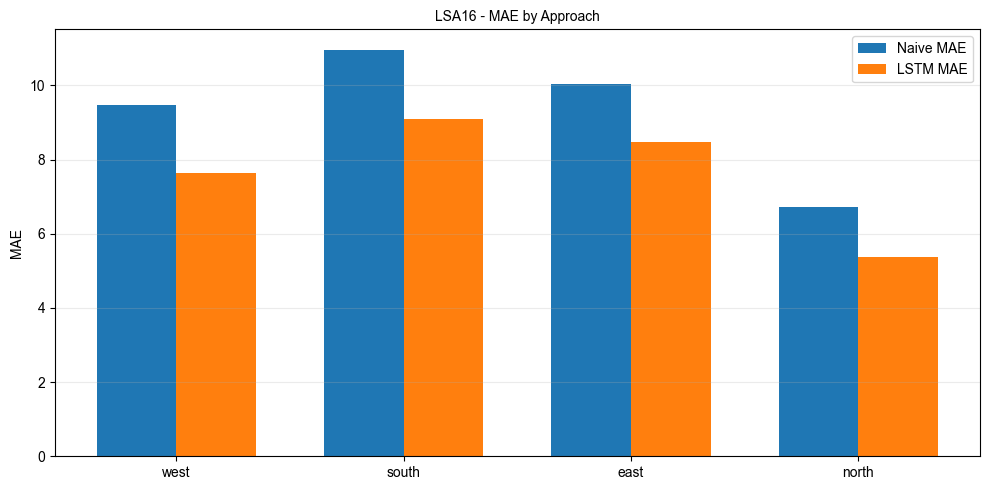

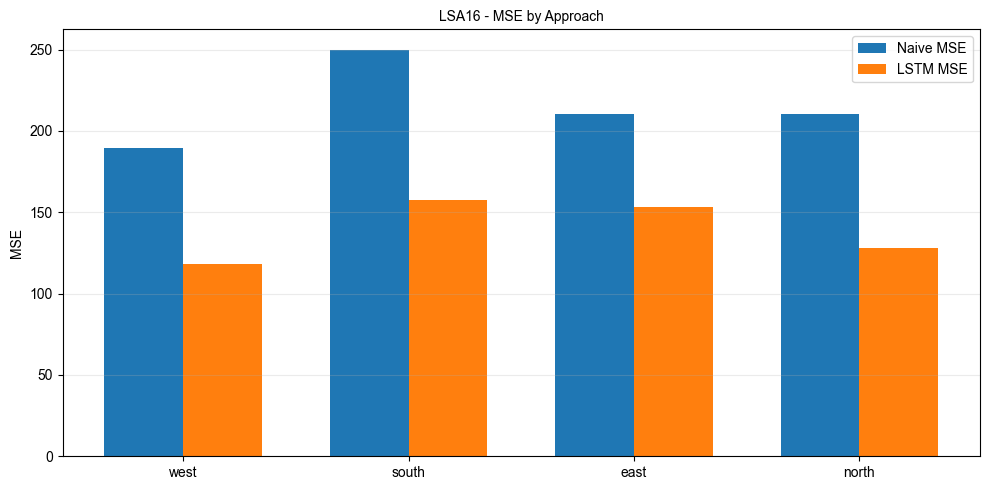

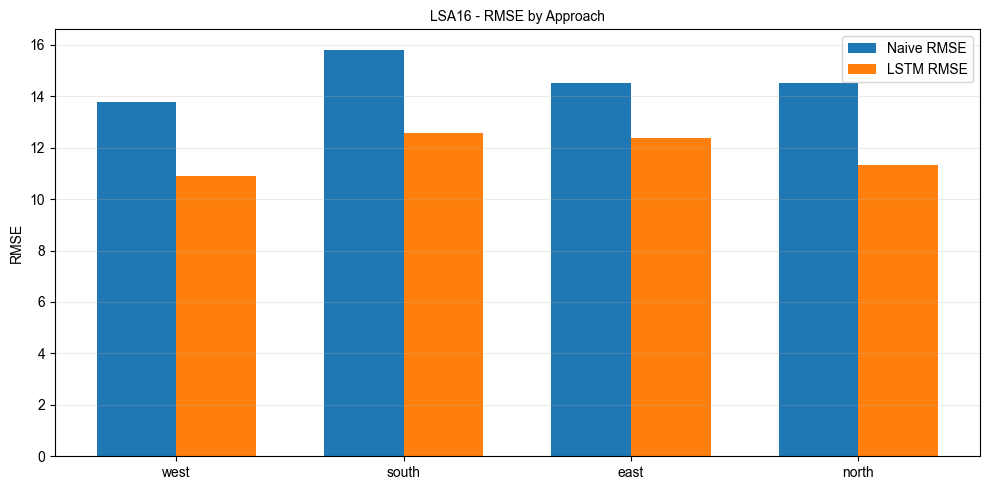

In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# PER-APPROACH METRICS
# ============================================================

rows = []

for i, feature in enumerate(count_cols):
    approach_name = feature.replace("LSA16_", "").replace("_count", "")

    naive_mae = mean_absolute_error(y_test_actual[:, i], y_pred_naive_actual[:, i])
    lstm_mae = mean_absolute_error(y_test_actual[:, i], y_pred_lstm_actual[:, i])

    naive_mse = mean_squared_error(y_test_actual[:, i], y_pred_naive_actual[:, i])
    lstm_mse = mean_squared_error(y_test_actual[:, i], y_pred_lstm_actual[:, i])

    naive_rmse = np.sqrt(naive_mse)
    lstm_rmse = np.sqrt(lstm_mse)

    rows.append({
        "approach": approach_name,
        "naive_MAE": naive_mae,
        "lstm_MAE": lstm_mae,
        "naive_MSE": naive_mse,
        "lstm_MSE": lstm_mse,
        "naive_RMSE": naive_rmse,
        "lstm_RMSE": lstm_rmse,
    })

per_feature_df = pd.DataFrame(rows)
print(per_feature_df)

# ============================================================
# PLOTS
# ============================================================

x = np.arange(len(per_feature_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, per_feature_df["naive_MAE"], width, label="Naive MAE")
plt.bar(x + width/2, per_feature_df["lstm_MAE"], width, label="LSTM MAE")
plt.xticks(x, per_feature_df["approach"])
plt.title("LSA16 - MAE by Approach")
plt.ylabel("MAE")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, per_feature_df["naive_MSE"], width, label="Naive MSE")
plt.bar(x + width/2, per_feature_df["lstm_MSE"], width, label="LSTM MSE")
plt.xticks(x, per_feature_df["approach"])
plt.title("LSA16 - MSE by Approach")
plt.ylabel("MSE")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, per_feature_df["naive_RMSE"], width, label="Naive RMSE")
plt.bar(x + width/2, per_feature_df["lstm_RMSE"], width, label="LSTM RMSE")
plt.xticks(x, per_feature_df["approach"])
plt.title("LSA16 - RMSE by Approach")
plt.ylabel("RMSE")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

**8)Visualization of actual, naive, and LSTM predictions for LSA16**
This step compares the observed traffic counts with the naive baseline and LSTM forecasts for the four LSA16 inflow approaches.

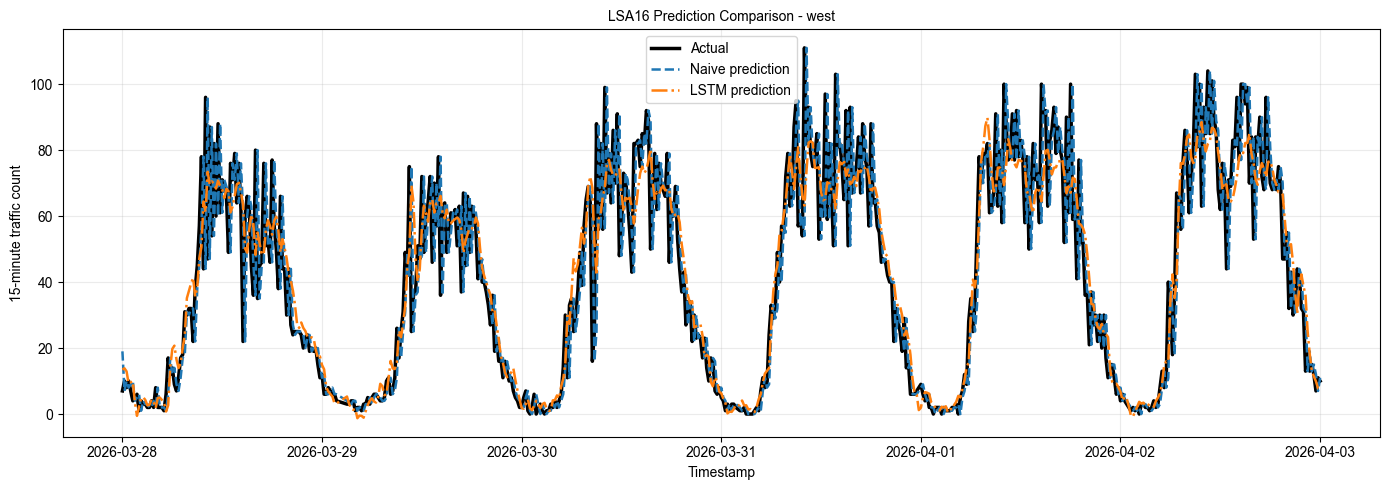

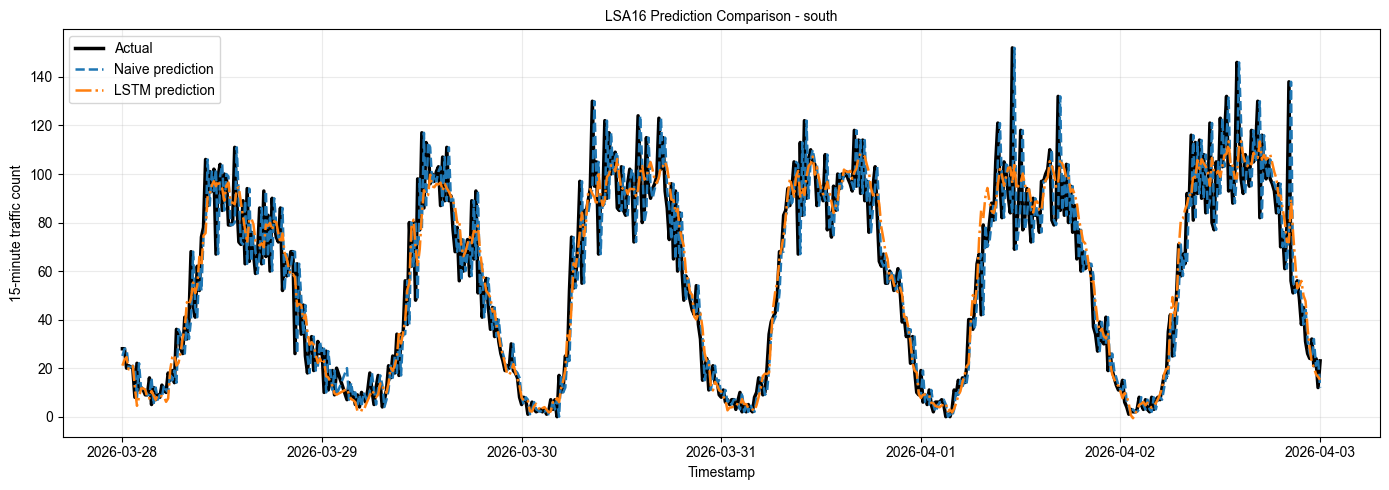

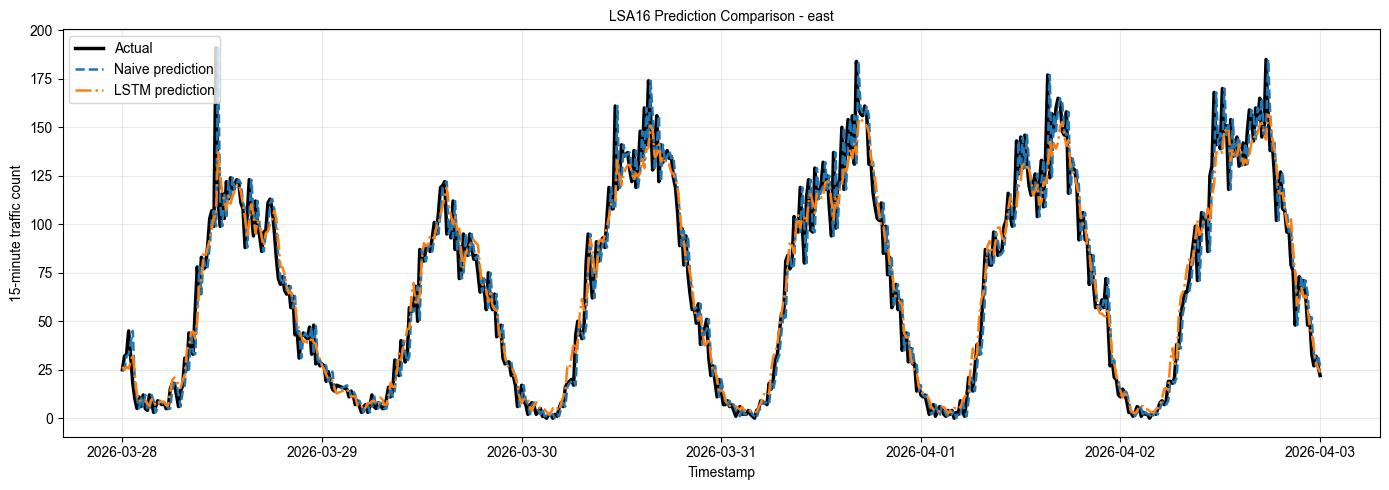

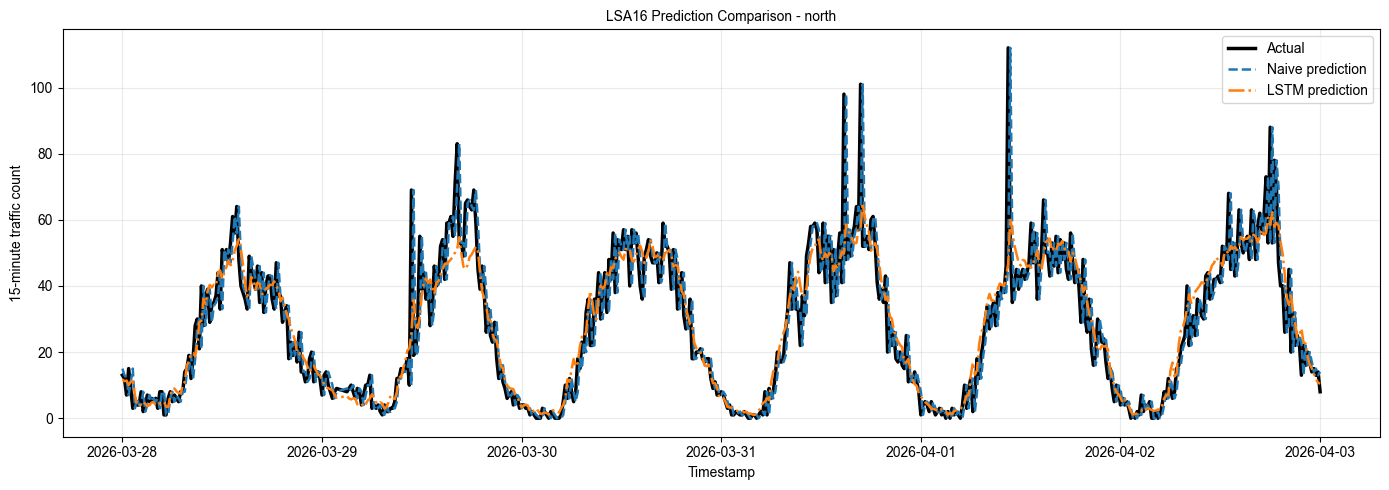

In [15]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================

plot_features = count_cols.copy()

# choose a shorter visible window inside the test period
# examples:
# window_start = "2026-03-28"
# window_end   = "2026-04-02"

window_start = "2026-03-28"
window_end   = "2026-04-03"

test_timestamps = test_df["timestamp_berlin"].iloc[LOOKBACK + HORIZON - 1:].reset_index(drop=True)

mask = (test_timestamps >= window_start) & (test_timestamps <= window_end)

plot_timestamps = test_timestamps[mask]

for feature in plot_features:
    idx = count_cols.index(feature)

    actual = y_test_actual[:, idx][mask]
    naive = y_pred_naive_actual[:, idx][mask]
    lstm = y_pred_lstm_actual[:, idx][mask]

    plt.figure(figsize=(14, 5))

    plt.plot(plot_timestamps, actual, label="Actual", linewidth=2.5, color="black")
    plt.plot(plot_timestamps, naive, label="Naive prediction", linestyle="--", linewidth=1.8)
    plt.plot(plot_timestamps, lstm, label="LSTM prediction", linestyle="-.", linewidth=1.8)

    plt.title(f"LSA16 Prediction Comparison - {feature.replace('LSA16_', '').replace('_count', '')}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

**Data Availability**

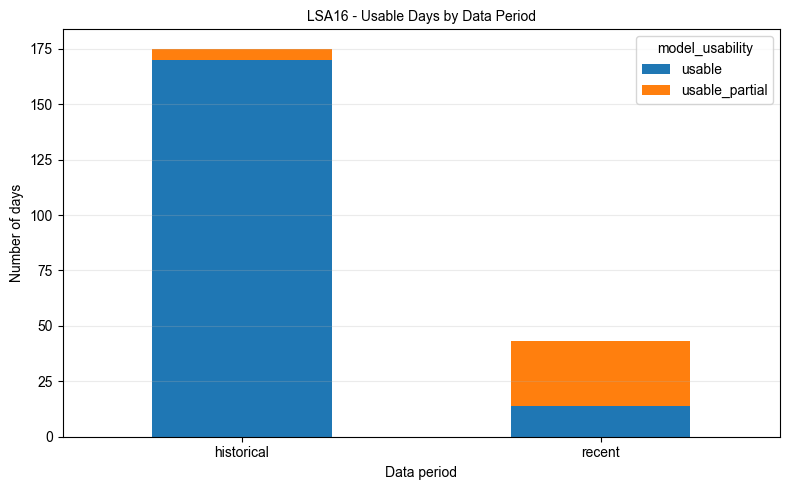

model_usability  usable  usable_partial
source_period                          
historical          170               5
recent               14              29


In [16]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA16")
USABLE_DAYS_CSV = BASE_DIR / "LSA16_usable_days.csv"

# ============================================================
# LOAD
# ============================================================

usable_days = pd.read_csv(USABLE_DAYS_CSV)

summary = (
    usable_days.groupby(["source_period", "model_usability"])
    .size()
    .unstack(fill_value=0)
)

# keep clean order
for col in ["usable", "usable_partial"]:
    if col not in summary.columns:
        summary[col] = 0

summary = summary[["usable", "usable_partial"]]

ax = summary.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_title("LSA16 - Usable Days by Data Period")
ax.set_xlabel("Data period")
ax.set_ylabel("Number of days")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(summary)

For LSA16, detector-level traffic counts were first aggregated to the approach level for the west, south, east, and north inflow directions. Based on the availability analysis, the historical 2025 dataset was used for training, while the more recent 2026 dataset was divided chronologically into validation and test subsets. This blockwise strategy was chosen because the historical and recent datasets are separated by a long temporal gap and should therefore not be treated as one continuous time series. The traffic count variables were scaled using a MinMaxScaler fitted on the training data only. Afterwards, the multivariate time series was transformed into sequential input-output samples using a lookback window of four 15-minute intervals, corresponding to one hour of traffic history, to predict the next 15-minute traffic state. As a benchmark, a naive persistence baseline was used, assuming that the next traffic count is equal to the most recent observed value. The LSTM architecture consisted of one LSTM layer with 64 hidden units, followed by a dropout layer and a dense output layer for simultaneous prediction of the four approach counts. The model was trained for multiple epochs, where one epoch represents one full pass through the training dataset. The dropout layer randomly deactivates a proportion of neurons during training in order to reduce overfitting and improve generalization. Model performance was evaluated using MAE and RMSE, where MAE indicates the average absolute prediction error in vehicle counts and RMSE penalizes larger errors more strongly. The training and validation loss curves showed a stable learning process without severe overfitting, and the final results demonstrated that the LSTM outperformed the naive baseline for LSA16.

**Epoch**

An epoch means one full pass through the training dataset.
If i train for 30 epochs, the model sees the full training data 30 times and updates its weights each time.

**Dropout**

Dropout is a regularization method. During training, it randomly ignores a fraction of neurons, here 20%, so that the model does not rely too heavily on specific patterns. This helps reduce overfitting and improves generalization to unseen data.

**Training loss**

The training loss is the model’s error on the training set during learning. It shows how well the model fits the data it is trained on.

**Validation loss**

The validation loss is the model’s error on unseen validation data after each epoch. It is important because it shows whether the model is learning patterns that generalize, rather than just memorizing the training data.

**MAE**

MAE means Mean Absolute Error. It tells, on average, how many vehicles the prediction is off by, without squaring the errors.

**RMSE**

RMSE means Root Mean Squared Error. It is similar to MAE but penalizes large errors more strongly. So it is more sensitive to spikes and bigger mistakes.

My result

For LSA16:

Naive MAE = 9.304
LSTM MAE = 7.542
Naive RMSE = 14.665
LSTM RMSE = 11.735

This means the LSTM made smaller average errors and also fewer large errors than the naive baseline.

In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 4
HORIZONS = [1, 2, 4]   # 15 min, 30 min, 60 min

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

def build_lstm_model(lookback, n_features):
    model = Sequential([
        LSTM(64, input_shape=(lookback, n_features)),
        Dropout(0.2),
        Dense(n_features)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# ============================================================
# SCALE USING TRAIN DATA ONLY
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[count_cols])

train_scaled = scaler.transform(train_df[count_cols])
val_scaled   = scaler.transform(val_df[count_cols])
test_scaled  = scaler.transform(test_df[count_cols])

# ============================================================
# LOOP OVER HORIZONS
# ============================================================

results = []

for horizon in HORIZONS:
    print("=" * 70)
    print(f"HORIZON = {horizon} step(s) = {horizon * 15} minutes ahead")

    # create sequences
    X_train, y_train = create_sequences(train_scaled, LOOKBACK, horizon)
    X_val, y_val     = create_sequences(val_scaled, LOOKBACK, horizon)
    X_test, y_test   = create_sequences(test_scaled, LOOKBACK, horizon)

    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
    print("X_test: ", X_test.shape, "y_test:", y_test.shape)

    # actual values in original scale
    y_test_actual = scaler.inverse_transform(y_test)

    # ========================================================
    # NAIVE BASELINE
    # ========================================================
    y_pred_naive_scaled = X_test[:, -1, :]
    y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

    overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
    overall_rmse_naive = rmse(y_test_actual, y_pred_naive_actual)

    # ========================================================
    # LSTM
    # ========================================================
    n_features = X_train.shape[2]

    model = build_lstm_model(LOOKBACK, n_features)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred_lstm_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

    overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
    overall_rmse_lstm = rmse(y_test_actual, y_pred_lstm_actual)

    print("Naive  -> MAE:", round(overall_mae_naive, 3), "| RMSE:", round(overall_rmse_naive, 3))
    print("LSTM   -> MAE:", round(overall_mae_lstm, 3), "| RMSE:", round(overall_rmse_lstm, 3))

    results.append({
        "horizon_steps": horizon,
        "horizon_minutes": horizon * 15,
        "naive_MAE": overall_mae_naive,
        "naive_RMSE": overall_rmse_naive,
        "lstm_MAE": overall_mae_lstm,
        "lstm_RMSE": overall_rmse_lstm,
        "mae_improvement_percent": (overall_mae_naive - overall_mae_lstm) / overall_mae_naive * 100,
        "rmse_improvement_percent": (overall_rmse_naive - overall_rmse_lstm) / overall_rmse_naive * 100,
        "best_val_loss": min(history.history["val_loss"]),
        "epochs_trained": len(history.history["loss"])
    })

results_df = pd.DataFrame(results)

print("\nFinal comparison table:")
print(results_df)

HORIZON = 1 step(s) = 15 minutes ahead
X_train: (16710, 4, 4) y_train: (16710, 4)
X_val:   (1983, 4, 4) y_val: (1983, 4)
X_test:  (1983, 4, 4) y_test: (1983, 4)


c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Naive  -> MAE: 9.304 | RMSE: 14.665
LSTM   -> MAE: 7.618 | RMSE: 11.788
HORIZON = 2 step(s) = 30 minutes ahead
X_train: (16709, 4, 4) y_train: (16709, 4)
X_val:   (1982, 4, 4) y_val: (1982, 4)
X_test:  (1982, 4, 4) y_test: (1982, 4)


c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Naive  -> MAE: 9.754 | RMSE: 15.357
LSTM   -> MAE: 8.052 | RMSE: 12.355
HORIZON = 4 step(s) = 60 minutes ahead
X_train: (16707, 4, 4) y_train: (16707, 4)
X_val:   (1980, 4, 4) y_val: (1980, 4)
X_test:  (1980, 4, 4) y_test: (1980, 4)


c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Naive  -> MAE: 12.096 | RMSE: 17.956
LSTM   -> MAE: 9.464 | RMSE: 13.849

Final comparison table:
   horizon_steps  horizon_minutes  naive_MAE  naive_RMSE  lstm_MAE  lstm_RMSE  \
0              1               15   9.303580   14.665311  7.617566  11.788245   
1              2               30   9.754036   15.357299  8.051685  12.355481   
2              4               60  12.096086   17.956095  9.463863  13.848638   

   mae_improvement_percent  rmse_improvement_percent  best_val_loss  \
0                18.122213                 19.618171       0.004121   
1                17.452787                 19.546524       0.004446   
2                21.760946                 22.875000       0.005724   

   epochs_trained  
0              23  
1              24  
2              15  


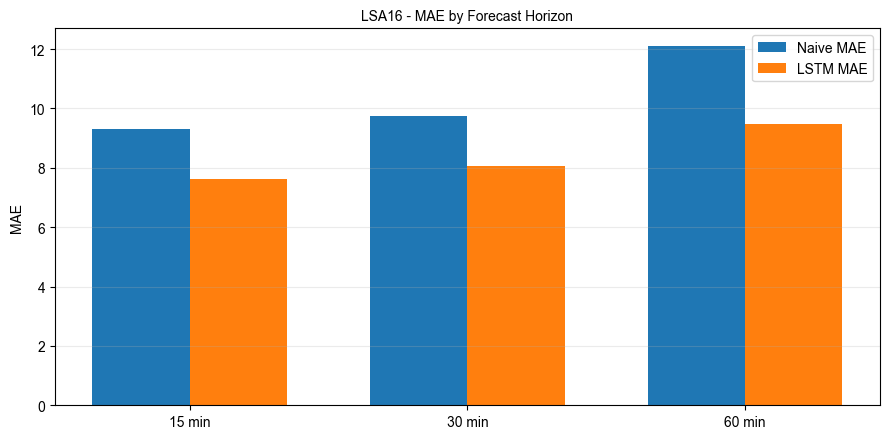

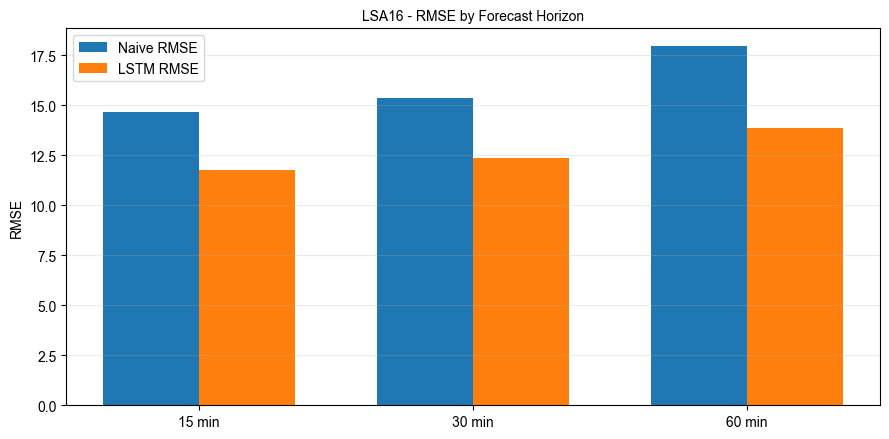

In [18]:
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
import numpy as np

x = np.arange(len(results_df))
labels = [f"{m} min" for m in results_df["horizon_minutes"]]

width = 0.35

# MAE
plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, results_df["naive_MAE"], width, label="Naive MAE")
plt.bar(x + width/2, results_df["lstm_MAE"], width, label="LSTM MAE")
plt.xticks(x, labels)
plt.ylabel("MAE")
plt.title("LSA16 - MAE by Forecast Horizon")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# RMSE
plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, results_df["naive_RMSE"], width, label="Naive RMSE")
plt.bar(x + width/2, results_df["lstm_RMSE"], width, label="LSTM RMSE")
plt.xticks(x, labels)
plt.ylabel("RMSE")
plt.title("LSA16 - RMSE by Forecast Horizon")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

The LSA16 results demonstrate that the LSTM model provides clear predictive value over the naive baseline, particularly for longer horizons, suggesting that sequence-based learning is beneficial when short-term persistence becomes less informative.